# HIFtool DHIF-Net — CAVE Dataset Evaluation

In [23]:
!pip install torch==2.4.1 torchvision==0.19.1 --index-url https://download.pytorch.org/whl/cu121 -q
!pip install imgvision einops scipy timm --no-deps -q
!pip install timm -q


In [24]:
import os, sys, glob, argparse, time
import numpy as np, torch, torch.nn as nn
import scipy.io as sio, torch.utils.data as data
import matplotlib.pyplot as plt, imgvision as iv

device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
print(f'Device: {device}  |  PyTorch: {torch.__version__}')

DATA_ROOT = '/kaggle/input/cave-dataset-2/Data'
if os.path.exists(DATA_ROOT) and not os.path.exists(os.path.join(DATA_ROOT, 'HSI')):
    if os.path.exists(os.path.join(DATA_ROOT, 'Test', 'HSI')):
        DATA_ROOT = os.path.join(DATA_ROOT, 'Test')
    elif os.path.exists(os.path.join(DATA_ROOT, 'test', 'HSI')):
        DATA_ROOT = os.path.join(DATA_ROOT, 'test')
if not os.path.exists(DATA_ROOT):
    possible_roots = glob.glob('/kaggle/input/**/Data/Test', recursive=True)
    if possible_roots: DATA_ROOT = possible_roots[0]

possible_ckpts = ['/kaggle/input/dhif-net-best/pytorch/default/1/model_best.pth']
if not os.path.exists(possible_ckpts[0]):
    possible_ckpts = sorted(glob.glob('/kaggle/input/models/**/*.pth', recursive=True))
CKPT_PATH = possible_ckpts[0] if possible_ckpts else None
print(f'Data root: {DATA_ROOT}')
print(f'Checkpoint: {CKPT_PATH}')


Device: cuda  |  PyTorch: 2.4.1+cu121
Data root: /kaggle/input/cave-dataset-2/Data/Test
Checkpoint: /kaggle/input/dhif-net-best/pytorch/default/1/model_best.pth


## Model & Utils

In [25]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Copyright (c) 2015 IAS / CNRS / Univ. Paris-Sud
# BSD License - see attached LICENSE file
# Author: Alexandre Boucaud <alexandre.boucaud@ias.u-psud.fr>

"""
PyPHER - Python-based PSF Homogenization kERnels
================================================

Compute the homogenization kernel between two PSFs

Usage:
  pypher psf_source psf_target output
         [-s ANGLE_SOURCE] [-t ANGLE_TARGET] [-r REG_FACT]
  pypher (-h | --help)

Example:
  pypher psf_a.fits psf_b.fits kernel_a_to_b.fits -r 1.e-5
"""
from __future__ import absolute_import, print_function, division

import os
import sys
import logging
import logging.handlers
import argparse
import numpy as np

from scipy.ndimage import rotate, zoom

# from . import fitsutils as fits
# from .parser import ThrowingArgumentParser, ArgumentParserError

__version__ = '0.6.4'


# def parse_args():
#     """Argument parser for the command line interface of `pypher`"""
#     parser = ThrowingArgumentParser(
#         formatter_class=argparse.ArgumentDefaultsHelpFormatter,
#         prog='pypher',
#         description="Compute the homogenization kernel between two PSFs")
#
#     parser.add_argument('psf_source', type=str,
#                         help="FITS file of PSF image with highest resolution")
#
#     parser.add_argument('psf_target', type=str,
#                         help="FITS file of PSF image with lowest resolution")
#
#     parser.add_argument('output', type=str,
#                         help="File name for the output kernel")
#
#     parser.add_argument('-s', '--angle_source', type=float, default=0.0,
#                         help="Rotation angle to apply to `psf_source` (deg)")
#
#     parser.add_argument('-t', '--angle_target', type=float, default=0.0,
#                         help="Rotation angle to apply to `psf_target` (deg)")
#
#     parser.add_argument('-r', '--reg_fact', type=float, default=1.e-4,
#                         help="Regularisation parameter for the Wiener filter")
#
#     return parser.parse_args()

################
# IMAGE METHODS
################


# def format_kernel_header(fits_file, args, pixel_scale):
#     """
#     Write the input parameters of pypher as comments in the header
#
#     The kernel header therefore contains the name of the PSF files
#     it has been created from.
#     The pixel scale of the kernel is also written as a dedicated
#     kernel key.
#
#     Parameters
#     ----------
#     fits_file: str
#         Path to the FITS kernel image
#     args: `argparse.Namespace`
#         Container for the parsed values
#     pixel_scale: float
#         Pixel scale of the kernel
#
#     """
#     fits.clear_comments(fits_file)
#
#     pypher_comments = [
#         '=' * 50, '',
#         'File written with PyPHER',
#         '------------------------', '',
#         'Kernel from PSF', '',
#         '=> {0}'.format(os.path.basename(args.psf_source)), '',
#         'to PSF', '',
#         '=> {0}'.format(os.path.basename(args.psf_target)), '',
#         'using a regularisation parameter '
#         'R = {0:1.1e}'.format(args.reg_fact), '',
#         '=' * 50
#     ]
#     fits.add_comments(fits_file, pypher_comments)
#
#     fits.write_pixelscale(fits_file, pixel_scale)


def imrotate(image, angle, interp_order=1):
    """
    Rotate an image from North to East given an angle in degrees

    Parameters
    ----------
    image : `numpy.ndarray`
        Input data array
    angle : float
        Angle in degrees
    interp_order : int, optional
        Spline interpolation order [0, 5] (default 1: linear)

    Returns
    -------
    output : `numpy.ndarray`
        Rotated data array

    """
    return rotate(image, -1.0 * angle,
                  order=interp_order, reshape=False, prefilter=False)


def imresample(image, source_pscale, target_pscale, interp_order=1):
    """
    Resample data array from one pixel scale to another

    The resampling ensures the parity of the image is conserved
    to preserve the centering.

    Parameters
    ----------
    image : `numpy.ndarray`
        Input data array
    source_pscale : float
        Pixel scale of ``image`` in arcseconds
    target_pscale : float
        Pixel scale of output array in arcseconds
    interp_order : int, optional
        Spline interpolation order [0, 5] (default 1: linear)

    Returns
    -------
    output : `numpy.ndarray`
        Resampled data array

    """
    old_size = image.shape[0]
    new_size_raw = old_size * source_pscale / target_pscale
    new_size = int(np.ceil(new_size_raw))

    if new_size > 10000:
        raise MemoryError("The resampling will yield a too large image. "
                          "Please resize the input PSF image.")

    # Chech for parity
    if (old_size - new_size) % 2 == 1:
        new_size += 1

    ratio = new_size / old_size

    return zoom(image, ratio, order=interp_order) / ratio**2


def trim(image, shape):
    """
    Trim image to a given shape

    Parameters
    ----------
    image: 2D `numpy.ndarray`
        Input image
    shape: tuple of int
        Desired output shape of the image

    Returns
    -------
    new_image: 2D `numpy.ndarray`
        Input image trimmed

    """
    shape = np.asarray(shape, dtype=int)
    imshape = np.asarray(image.shape, dtype=int)

    if np.all(imshape == shape):
        return image

    if np.any(shape <= 0):
        raise ValueError("TRIM: null or negative shape given")

    dshape = imshape - shape
    if np.any(dshape < 0):
        raise ValueError("TRIM: target size bigger than source one")

    if np.any(dshape % 2 != 0):
        raise ValueError("TRIM: source and target shapes "
                         "have different parity")

    idx, idy = np.indices(shape)
    offx, offy = dshape // 2

    return image[idx + offx, idy + offy]


def zero_pad(image, shape, position='corner'):
    """
    Extends image to a certain size with zeros

    Parameters
    ----------
    image: real 2d `numpy.ndarray`
        Input image
    shape: tuple of int
        Desired output shape of the image
    position : str, optional
        The position of the input image in the output one:
            * 'corner'
                top-left corner (default)
            * 'center'
                centered

    Returns
    -------
    padded_img: real `numpy.ndarray`
        The zero-padded image

    """
    shape = np.asarray(shape, dtype=int)
    imshape = np.asarray(image.shape, dtype=int)

    if np.all(imshape == shape):
        return image

    if np.any(shape <= 0):
        raise ValueError("ZERO_PAD: null or negative shape given")

    dshape = shape - imshape
    if np.any(dshape < 0):
        raise ValueError("ZERO_PAD: target size smaller than source one")

    pad_img = np.zeros(shape, dtype=image.dtype)

    idx, idy = np.indices(imshape)

    if position == 'center':
        if np.any(dshape % 2 != 0):
            raise ValueError("ZERO_PAD: source and target shapes "
                             "have different parity.")
        offx, offy = dshape // 2
    else:
        offx, offy = (0, 0)

    pad_img[idx + offx, idy + offy] = image

    return pad_img


##########
# FOURIER
##########


def udft2(image):
    """Unitary fft2"""
    norm = np.sqrt(image.size)
    return np.fft.fft2(image) / norm


def uidft2(image):
    """Unitary ifft2"""
    norm = np.sqrt(image.size)
    return np.fft.ifft2(image) * norm


def psf2otf(psf, shape):
    """
    Convert point-spread function to optical transfer function.

    Compute the Fast Fourier Transform (FFT) of the point-spread
    function (PSF) array and creates the optical transfer function (OTF)
    array that is not influenced by the PSF off-centering.
    By default, the OTF array is the same size as the PSF array.

    To ensure that the OTF is not altered due to PSF off-centering, PSF2OTF
    post-pads the PSF array (down or to the right) with zeros to match
    dimensions specified in OUTSIZE, then circularly shifts the values of
    the PSF array up (or to the left) until the central pixel reaches (1,1)
    position.

    Parameters
    ----------
    psf : `numpy.ndarray`
        PSF array
    shape : int
        Output shape of the OTF array

    Returns
    -------
    otf : `numpy.ndarray`
        OTF array

    Notes
    -----
    Adapted from MATLAB psf2otf function

    """
    if np.all(psf == 0):
        return np.zeros_like(psf)

    inshape = psf.shape
    # Pad the PSF to outsize
    psf = zero_pad(psf, shape, position='corner')

    # Circularly shift OTF so that the 'center' of the PSF is
    # [0,0] element of the array
    for axis, axis_size in enumerate(inshape):
        psf = np.roll(psf, -int(axis_size / 2), axis=axis)

    # Compute the OTF
    otf = np.fft.fft2(psf)

    # Estimate the rough number of operations involved in the FFT
    # and discard the PSF imaginary part if within roundoff error
    # roundoff error  = machine epsilon = sys.float_info.epsilon
    # or np.finfo().eps
    n_ops = np.sum(psf.size * np.log2(psf.shape))
    otf = np.real_if_close(otf, tol=n_ops)

    return otf


################
# DECONVOLUTION
################

LAPLACIAN = np.array([[ 0, -1,  0],
                      [-1,  4, -1],
                      [ 0, -1,  0]])


def deconv_wiener(psf, reg_fact):
    r"""
    Create a Wiener filter using a PSF image

    The signal is $\ell_2$ penalized by a 2D Laplacian operator that
    serves as a high-pass filter for the regularization process.
    The key to the process is to use optical transfer functions (OTF)
    instead of simple Fourier transform, since it ensures the phase
    of the psf is adequately placed.

    Parameters
    ----------
    psf: `numpy.ndarray`
        PSF array
    reg_fact: float
        Regularisation parameter for the Wiener filter

    Returns
    -------
    wiener: complex `numpy.ndarray`
        Fourier space Wiener filter

    """
    # Optical transfer functions
    trans_func = psf2otf(psf, psf.shape)
    reg_op = psf2otf(LAPLACIAN, psf.shape)

    wiener = np.conj(trans_func) / (np.abs(trans_func)**2 +
                                    reg_fact * np.abs(reg_op)**2)

    return wiener


def homogenization_kernel(psf_target, psf_source, reg_fact=1e-4, clip=True):
    r"""
    Compute the homogenization kernel to match two PSFs

    The deconvolution step is done using a Wiener filter with $\ell_2$
    penalization.
    The output is given both in Fourier and in the image domain to serve
    different purposes.

    Parameters
    ----------
    psf_target: `numpy.ndarray`
        2D array
    psf_source: `numpy.ndarray`
        2D array
    reg_fact: float, optional
        Regularisation parameter for the Wiener filter
    clip: bool, optional
        If `True`, enforces the non-amplification of the noise
        (default `True`)

    Returns
    -------
    kernel_image: `numpy.ndarray`
        2D deconvolved image
    kernel_fourier: `numpy.ndarray`
        2D discrete Fourier transform of deconvolved image

    """
    wiener = deconv_wiener(psf_source, reg_fact)

    kernel_fourier = wiener * udft2(psf_target)
    kernel_image = np.real(uidft2(kernel_fourier))

    if clip:
        kernel_image.clip(-1, 1)

    return kernel_image, kernel_fourier


########
# DEBUG
########


def setup_logger(log_filename='pypher.log'):  # pragma: no cover
    """
    Set up and return a logger

    The logger records the time, modulename, method and message

    Parameters
    ----------
    log_filename: str
        Name of the output logfile

    """
    # create logger
    logger = logging.getLogger('logger')
    logger.setLevel(logging.DEBUG)
    # Add the log message handler to the logger
    handler = logging.handlers.RotatingFileHandler(log_filename)
    # create formatter
    formatter = logging.Formatter('%(asctime)s - '
                                  '%(module)s - '
                                  '%(levelname)s - '
                                  '%(message)s')
    handler.setFormatter(formatter)
    # add handler to logger
    logger.addHandler(handler)

    return logger


#######
# MAIN
#######


# def main():  # pragma: no cover
#     """Main script for pypher"""
#     try:
#         args = parse_args()
#     except ArgumentParserError:
#         print(__doc__)
#         sys.exit()
#
#     kernel_basename, _ = os.path.splitext(args.output)
#     kernel_fits = kernel_basename + '.fits'
#
#     logname = '%s.log' % kernel_basename
#     if os.path.exists(logname):
#         os.remove(logname)
#     log = setup_logger(logname)
#
#     # Load images (NaNs are set to 0)
#     psf_source = fits.getdata(args.psf_source)
#     psf_target = fits.getdata(args.psf_target)
#
#     log.info('Source PSF loaded: %s', args.psf_source)
#     log.info('Target PSF loaded: %s', args.psf_target)
#
#     # Set NaNs to 0.0
#     psf_source = np.nan_to_num(psf_source)
#     psf_target = np.nan_to_num(psf_target)
#
#     # Retrieve the pixel scale of each image
#     pixscale_source = fits.get_pixscale(args.psf_source)
#     pixscale_target = fits.get_pixscale(args.psf_target)
#
#     log.info('Source PSF pixel scale: %.2f arcsec', pixscale_source)
#     log.info('Target PSF pixel scale: %.2f arcsec', pixscale_target)
#
#     # Rotate images (if necessary)
#     if args.angle_source != 0.0:
#         psf_source = imrotate(psf_source, args.angle_source)
#     if args.angle_target != 0.0:
#         psf_target = imrotate(psf_target, args.angle_target)
#
#     log.info('Source PSF rotated by %.2f degrees', args.angle_source)
#     log.info('Target PSF rotated by %.2f degrees', args.angle_target)
#
#     # Normalize the PSFs
#     psf_source /= psf_source.sum()
#     psf_target /= psf_target.sum()
#
#     # Resample high resolution image to the low one
#     if pixscale_source != pixscale_target:
#         try:
#             psf_source = imresample(psf_source,
#                                     pixscale_source,
#                                     pixscale_target)
#         except MemoryError:
#             log.error('- COMPUTATION ABORTED -')
#             log.error('The size of the resampled PSF would have '
#                       'exceeded 10K x 10K')
#             log.error('Please resize your image and try again')
#
#             print('Issue during the resampling step - see pypher.log')
#             sys.exit()
#
#         log.info('Source PSF resampled to the target pixel scale')
#
#     # check the new size of the source vs. the target
#     if psf_source.shape > psf_target.shape:
#         psf_source = trim(psf_source, psf_target.shape)
#     else:
#         psf_source = zero_pad(psf_source, psf_target.shape, position='center')
#
#     kernel, _ = homogenization_kernel(psf_target, psf_source,
#                                       reg_fact=args.reg_fact)
#
#     log.info('Kernel computed using Wiener filtering and a regularisation '
#              'parameter r = %.2e', args.reg_fact)
#
#     # Write kernel to FITS file
#     fits.writeto(kernel_fits, data=kernel)
#     format_kernel_header(kernel_fits, args, pixscale_target)
#
#     log.info('Kernel saved in %s', kernel_fits)
#
#     print("pypher: Output kernel saved to %s" % kernel_fits)
#
#
# if __name__ == '__main__':
#     main()


In [26]:
import numpy as np
import scipy.io as sio
import os
import glob
import torch
import torch.nn as nn
import skimage.measure as measure
import torch.nn.functional as F
import cv2

import random
import re
import math
try:
    # Prefer modern skimage API
    from skimage.metrics import structural_similarity as _ssim_metric
except Exception:
    _ssim_metric = None


def _as_floats(im1, im2):
    float_type = np.result_type(im1.dtype, im2.dtype, np.float32)
    im1 = np.asarray(im1, dtype=float_type)
    im2 = np.asarray(im2, dtype=float_type)
    return im1, im2


def compare_mse(im1, im2):
    im1, im2 = _as_floats(im1, im2)
    return np.mean(np.square(im1 - im2), dtype=np.float64)


def compare_psnr(im_true, im_test, data_range=None):
    im_true, im_test = _as_floats(im_true, im_test)

    err = compare_mse(im_true, im_test)
    return 10 * np.log10((data_range ** 2) / err)

def psnr(img1, img2):
   mse = np.mean((img1/255. - img2/255.) ** 2)
   if mse < 1.0e-10:
      return 100
   PIXEL_MAX = 1
   return 20 * math.log10(PIXEL_MAX / math.sqrt(mse))


def PSNR_GPU(im_true, im_fake):
    im_true *= 255
    im_fake *= 255
    im_true = im_true.round()
    im_fake = im_fake.round()
    data_range = 255
    esp = 1e-12
    C = im_true.size()[0]
    H = im_true.size()[1]
    W = im_true.size()[2]
    Itrue = im_true.clone()
    Ifake = im_fake.clone()
    mse = nn.MSELoss(reduce=False)
    err = mse(Itrue, Ifake).sum() / (C*H*W)
    psnr = 10. * np.log((data_range**2)/(err.data + esp)) / np.log(10.)
    return psnr

def PSNR_Nssr(im_true, im_fake):
    mse = ((im_true - im_fake)**2).mean()
    psnr = 10. * np.log10(1/mse)
    return psnr

def c_psnr(im1, im2):
    '''
    Compute PSNR
    :param im1: input image 1 ndarray ranging [0,1]
    :param im2: input image 2 ndarray ranging [0,1]
    :return: psnr=-10*log(mse(im1,im2))
    '''
    # mse = np.power(im1 - im2, 2).mean()
    # psnr = 20 * np.log10(255.0) - 10 * np.log10(mse)
    im1 = np.maximum(np.minimum(im1, 1.0), 0.0)
    im2 = np.maximum(np.minimum(im2, 1.0), 0.0)
    return measure.compare_psnr(im1, im2)

def c_ssim(im1, im2):
    '''
    Compute PSNR
    :param im1: input image 1 ndarray ranging [0,1]
    :param im2: input image 2 ndarray ranging [0,1]
    :return: psnr=-10*log(mse(im1,im2))
    '''
    # mse = np.power(im1 - im2, 2).mean()
    # psnr = 20 * np.log10(255.0) - 10 * np.log10(mse)

    im1 = np.maximum(np.minimum(im1, 1.0), 0.0)
    im2 = np.maximum(np.minimum(im2, 1.0), 0.0)
    return measure.compare_ssim(im1, im2, win_size=11, data_range=1, gaussian_weights=True)


# ---------- New metrics: SAM, ERGAS, SSIM (numpy-based) ----------
def _ensure_chw_numpy(arr):
    """Ensure numpy array shape is (C, H, W). Accepts (B,C,H,W), (C,H,W), or (H,W,C).
    Uses conservative heuristics to distinguish CHW vs HWC.
    """
    a = np.asarray(arr)
    if a.ndim == 4:
        # Prefer NCHW if channel dim small (<=64); else if NHWC with last dim small
        if a.shape[1] <= 64:
            a = a[0]  # NCHW -> CHW
        elif a.shape[-1] <= 64:
            a = np.transpose(a[0], (2, 0, 1))  # NHWC -> CHW
        else:
            a = a[0]
    if a.ndim != 3:
        raise ValueError(f"Expected 3D or 4D array, got shape {a.shape}")
    # At this point a is 3D. Decide if CHW or HWC.
    C, H, W = a.shape[0], a.shape[1], a.shape[2]
    if C <= 64 and H >= 8 and W >= 8:
        # Likely CHW already
        return a
    if a.shape[-1] <= 64 and a.shape[0] >= 8 and a.shape[1] >= 8:
        # HWC -> CHW
        return np.transpose(a, (2, 0, 1))
    # Fallback: assume CHW
    return a

# Public alias for use in other modules
def ensure_chw_numpy(arr):
    """Public wrapper for ensuring (C,H,W) numpy arrays."""
    return _ensure_chw_numpy(arr)


def compute_sam(im_true, im_test, eps=1e-12, as_degrees=True):
    """
    Spectral Angle Mapper (per-pixel angle between spectra), averaged over all pixels.
    Inputs can be (B,C,H,W), (C,H,W), or (H,W,C) with values typically in [0,1].
    Returns the mean angle (degrees by default).
    """
    x = _ensure_chw_numpy(im_true).astype(np.float64)
    y = _ensure_chw_numpy(im_test).astype(np.float64)
    if x.shape != y.shape:
        raise ValueError(f"Shape mismatch in SAM: {x.shape} vs {y.shape}")
    C, H, W = x.shape
    x_flat = x.reshape(C, -1)
    y_flat = y.reshape(C, -1)
    nom = np.sum(x_flat * y_flat, axis=0)
    denom = np.linalg.norm(x_flat, axis=0) * np.linalg.norm(y_flat, axis=0)
    cosang = np.clip(nom / np.maximum(denom, eps), -1.0, 1.0)
    ang = np.arccos(cosang)
    # Mask invalid (zero vectors) to avoid skewing average
    valid = np.isfinite(ang)
    if as_degrees:
        ang = ang / np.pi * 180.0
    return float(np.mean(ang[valid]))


def compute_ergas(im_true, im_test, scale=8, eps=1e-12):
    """
    ERGAS metric (lower is better).
    ERGAS = 100 * (h/l) * sqrt( (1/N) * sum_i (RMSE_i / mu_i)^2 )
    where h/l is the scale ratio (use sf for upsampling factor), N is band count.
    """
    x = _ensure_chw_numpy(im_true).astype(np.float64)
    y = _ensure_chw_numpy(im_test).astype(np.float64)
    if x.shape != y.shape:
        raise ValueError(f"Shape mismatch in ERGAS: {x.shape} vs {y.shape}")
    C = x.shape[0]
    # Per-band RMSE and mean of reference
    rmse = np.sqrt(np.mean((x - y) ** 2, axis=(1, 2)))
    mu = np.mean(x, axis=(1, 2))
    term = (rmse / np.maximum(mu, eps)) ** 2
    # ERGAS = 100 * (h/l) * sqrt(mean((RMSE_i / mu_i)^2)), where h/l = 1/scale
    ergas = 100.0 * (1.0 / float(scale)) * np.sqrt(np.mean(term))
    return float(ergas)


def compute_ssim(im_true, im_test, data_range=1.0, gaussian_weights=True, win_size=11):
    """
    Mean SSIM across bands. If arrays are 2D, computes single SSIM. For hyperspectral,
    computes SSIM per band and returns the average.
    """
    x = np.asarray(im_true)
    y = np.asarray(im_test)
    if x.shape != y.shape:
        raise ValueError(f"Shape mismatch in SSIM: {x.shape} vs {y.shape}")
    # 2D case
    if x.ndim == 2:
        if _ssim_metric is not None:
            return float(_ssim_metric(x, y, data_range=data_range, gaussian_weights=gaussian_weights, win_size=win_size))
        else:
            # Fallback to deprecated API
            return float(measure.compare_ssim(x, y, data_range=data_range, gaussian_weights=gaussian_weights, win_size=win_size))
    # 3D or 4D
    x_chw = _ensure_chw_numpy(x)
    y_chw = _ensure_chw_numpy(y)
    C = x_chw.shape[0]
    scores = []
    for c in range(C):
        Xa = x_chw[c]
        Ya = y_chw[c]
        if _ssim_metric is not None:
            s = _ssim_metric(Xa, Ya, data_range=data_range, gaussian_weights=gaussian_weights, win_size=win_size)
        else:
            s = measure.compare_ssim(Xa, Ya, data_range=data_range, gaussian_weights=gaussian_weights, win_size=win_size)
        scores.append(float(s))
    return float(np.mean(scores))

def batch_PSNR(im_true, im_fake, data_range):
    N = im_true.size()[0]
    C = im_true.size()[1]
    H = im_true.size()[2]
    W = im_true.size()[3]
    Itrue = im_true.clone().resize_(N, C*H*W)
    Ifake = im_fake.clone().resize_(N, C*H*W)
    mse = nn.MSELoss(reduction='none')
    err = mse(Itrue, Ifake).sum(dim=1, keepdim=True).div_(C*H*W)
    psnr = 10.0 * torch.log10((data_range ** 2) / err)
    return psnr.mean()


def PSNR_GPU(im_true, im_fake):
    im_true *= 255
    im_fake *= 255
    im_true = im_true.round()
    im_fake = im_fake.round()
    data_range = 255
    esp = 1e-12
    C = im_true.size()[0]
    H = im_true.size()[1]
    W = im_true.size()[2]
    Itrue = im_true.clone()
    Ifake = im_fake.clone()
    mse = nn.MSELoss(reduce=False)
    err = mse(Itrue, Ifake).sum() / (C*H*W)
    psnr = 10. * np.log((data_range**2)/(err.data + esp)) / np.log(10.)
    return psnr

def batch_SAM_GPU(im_true, im_fake):
    N = im_true.size()[0]
    C = im_true.size()[1]
    H = im_true.size()[2]
    W = im_true.size()[3]
    Itrue = im_true.clone().resize_(N, C, H*W)
    Ifake = im_fake.clone().resize_(N, C, H*W)
    nom = torch.mul(Itrue, Ifake).sum(dim=1).resize_(N, H*W)
    denom1 = torch.pow(Itrue,2).sum(dim=1).sqrt_().resize_(N, H*W)
    denom2 = torch.pow(Ifake,2).sum(dim=1).sqrt_().resize_(N, H*W)
    sam = torch.div(nom, torch.mul(denom1, denom2)).acos_().resize_(N, H*W)
    sam = sam / np.pi * 180
    sam = torch.sum(sam) / (N*H*W)
    return sam

def SAM_GPU(im_true, im_fake):
    C = im_true.size()[0]
    H = im_true.size()[1]
    W = im_true.size()[2]
    esp = 1e-12
    Itrue = im_true.clone()#.resize_(C, H*W)
    Ifake = im_fake.clone()#.resize_(C, H*W)
    nom = torch.mul(Itrue, Ifake).sum(dim=0)#.resize_(H*W)
    denominator = Itrue.norm(p=2, dim=0, keepdim=True).clamp(min=esp) * \
                  Ifake.norm(p=2, dim=0, keepdim=True).clamp(min=esp)
    denominator = denominator.squeeze()
    sam = torch.div(nom, denominator).acos()
    sam[sam != sam] = 0
    sam_sum = torch.sum(sam) / (H * W) / np.pi * 180
    return sam_sum

def batch_SAM_CPU(im_true, im_fake):
    I_true = im_true.data.cpu().numpy()
    I_fake = im_fake.data.cpu().numpy()
    N = I_true.shape[0]
    C = I_true.shape[1]
    H = I_true.shape[2]
    W = I_true.shape[3]
    batch_sam = 0
    for i in range(N):
        true = I_true[i,:,:,:].reshape(C, H*W)
        fake = I_fake[i,:,:,:].reshape(C, H*W)
        nom = np.sum(np.multiply(true, fake), 0).reshape(H*W, 1)
        denom1 = np.sqrt(np.sum(np.square(true), 0)).reshape(H*W, 1)
        denom2 = np.sqrt(np.sum(np.square(fake), 0)).reshape(H*W, 1)
        sam = np.arccos(np.divide(nom,np.multiply(denom1,denom2))).reshape(H*W, 1)
        sam = sam/np.pi*180
        # ignore pixels that have zero norm
        idx = (np.isfinite(sam))
        batch_sam += np.sum(sam[idx])/np.sum(idx)
        if np.sum(~idx) != 0:
            print("waring: some values were ignored when computing SAM")
    return batch_sam/N

def SAM_CPU(im_true, im_fake):
    I_true = im_true.data.cpu().numpy()
    I_fake = im_fake.data.cpu().numpy()
    N = I_true.shape[0]
    C = I_true.shape[1]
    H = I_true.shape[2]
    W = I_true.shape[3]
    batch_sam = 0
    for i in range(N):
        true = I_true[i,:,:,:].reshape(C, H*W)
        fake = I_fake[i,:,:,:].reshape(C, H*W)
        nom = np.sum(np.multiply(true, fake), 0).reshape(H*W, 1)
        denom1 = np.sqrt(np.sum(np.square(true), 0)).reshape(H*W, 1)
        denom2 = np.sqrt(np.sum(np.square(fake), 0)).reshape(H*W, 1)
        sam = np.arccos(np.divide(nom,np.multiply(denom1,denom2))).reshape(H*W, 1)
        sam = sam/np.pi*180
        # ignore pixels that have zero norm
        idx = (np.isfinite(sam))
        batch_sam += np.sum(sam[idx])/np.sum(idx)
        if np.sum(~idx) != 0:
            print("waring: some values were ignored when computing SAM")
    return batch_sam/N


# Convert an image into patches
def Im2Patch(img,img2, win, stride=1, istrain=False): # Based on code written by Shuhang Gu (cssgu@comp.polyu.edu.hk)
    k = 0
    endw = img.shape[0]
    endh = img.shape[1]
    if endw<win or endh<win:
        return None,None
    patch = img[0:endw - win + 0 + 1:stride, 0:endh - win + 0 + 1:stride]
    TotalPatNum = patch.shape[0] * patch.shape[1]
    # TotalPatNum = (img.shape[0]-win+1)*(img.shape[1]-win+1)
    Y = np.zeros([win*win,TotalPatNum])
    Y2 = np.zeros([win*win,TotalPatNum])
    for i in range(win):
        for j in range(win):
            patch = img[i:endw-win+i+1:stride,j:endh-win+j+1:stride]
            Y[k,:] = np.array(patch[:]).reshape(TotalPatNum)
            patch2 = img2[i:endw - win + i + 1:stride, j:endh - win + j + 1:stride]
            Y2[k, :] = np.array(patch2[:]).reshape(TotalPatNum)
            k = k + 1
    if istrain:
        return Y.reshape([win, win, TotalPatNum]), Y2.reshape([win, win, TotalPatNum])
    else:
        return Y.transpose().reshape([TotalPatNum,win,win,1]), Y2.transpose().reshape([TotalPatNum,win,win,1])

def para_setting(kernel_type,sf,sz,sigma):
    if kernel_type ==  'uniform_blur':
        psf = np.ones([sf,sf]) / (sf *sf)
    elif kernel_type == 'gaussian_blur':
        psf = np.multiply(cv2.getGaussianKernel(sf, sigma), (cv2.getGaussianKernel(sf, sigma)).T)

    fft_B = psf2otf(psf, sz)
    fft_BT = np.conj(fft_B)
    return fft_B,fft_BT


def H_z(z, factor, fft_B ):
    #     z  [31 , 96 , 96]
    #     ch, h, w = z.shape
    # Use torch.fft APIs (rfft/irfft deprecated)
    device = z.device
    if len(z.shape) == 3:
        ch, h, w = z.shape
        f = torch.fft.fft2(z, dim=(-2, -1))
        fft_B_c = torch.complex(fft_B[:, :, 0].to(device), fft_B[:, :, 1].to(device))
        M = f * fft_B_c
        Hz = torch.fft.ifft2(M, dim=(-2, -1)).real
        x = Hz[:, int(factor // 2)::factor, int(factor // 2)::factor]
    elif len(z.shape) == 4:
        bs, ch, h, w = z.shape
        f = torch.fft.fft2(z, dim=(-2, -1))
        fft_B_c = torch.complex(fft_B[:, :, 0].to(device), fft_B[:, :, 1].to(device)).unsqueeze(0).unsqueeze(0)
        M = f * fft_B_c
        Hz = torch.fft.ifft2(M, dim=(-2, -1)).real
        x = Hz[:, :, int(factor // 2)::factor, int(factor // 2)::factor]
    return x

def HT_y(y, sf, fft_BT):
    device = y.device
    if len(y.shape) == 3:
        ch, w, h = y.shape
        z = F.pad(y, [0, 0, 0, 0, 0, sf * sf - 1], "constant", value=0)
        z = F.pixel_shuffle(z, upscale_factor=sf).view(1, ch, w * sf, h * sf)

        f = torch.fft.fft2(z, dim=(-2, -1))
        fft_BT_c = torch.complex(fft_BT[:, :, 0].to(device), fft_BT[:, :, 1].to(device))
        # broadcast fft_BT over ch as needed
        fft_BT_c = fft_BT_c.unsqueeze(0).repeat(ch, 1, 1)
        # Match f shape [1,ch,h,w] by unsqueeze
        M = f * fft_BT_c.unsqueeze(0)
        Hz = torch.fft.ifft2(M, dim=(-2, -1)).real
    elif len(y.shape) == 4:
        bs, ch, w, h = y.shape
        z = y.view(-1, 1, w, h)
        z = F.pad(z, [0, 0, 0, 0, 0, sf * sf - 1, 0, 0], "constant", value=0)
        z = F.pixel_shuffle(z, upscale_factor=sf).view(bs, ch, w * sf, h * sf)

        f = torch.fft.fft2(z, dim=(-2, -1))
        fft_BT_c = torch.complex(fft_BT[:, :, 0].to(device), fft_BT[:, :, 1].to(device)).unsqueeze(0).unsqueeze(0)
        M = f * fft_BT_c
        Hz = torch.fft.ifft2(M, dim=(-2, -1)).real
    return Hz

def dataparallel(model, ngpus, gpu0=0):
    """
    Wrap    model with DataParallel if CUDA is available and requested; otherwise run on CPU.
    This avoids hard-failing in environments without GPU (e.g., Kaggle CPU sessions).
    """
    has_cuda = torch.cuda.is_available()
    if has_cuda and ngpus >= 1 and torch.cuda.device_count() >= gpu0 + ngpus:
        gpu_list = list(range(gpu0, gpu0 + ngpus))
        if ngpus > 1:
            if not isinstance(model, torch.nn.DataParallel):
                model = torch.nn.DataParallel(model, gpu_list).cuda()
            else:
                model = model.cuda()
        else:
            model = model.cuda()
        return model
    else:
        print("[Warning] CUDA not available or insufficient GPUs; running on CPU.")
        return model.cpu()

def findLastCheckpoint(save_dir):
    file_list = glob.glob(os.path.join(save_dir, 'model_*.pth'))
    epochs = []
    for file_ in file_list:
        # Only match numeric suffixes like model_001.pth
        m = re.search(r"model_(\d+)\.pth$", os.path.basename(file_))
        if m:
            try:
                epochs.append(int(m.group(1)))
            except ValueError:
                pass
    return max(epochs) if epochs else 0

def prepare_data(path, file_list, file_num):
    HR_HSI = np.zeros((((512,512,31,file_num))))
    HR_MSI = np.zeros((((512,512,3,file_num))))
    for idx in range(file_num):
        ####  read HrHSI
        HR_code = file_list[idx]
        path1 = os.path.join(path, 'HSI/') + HR_code + '.mat'
        data = sio.loadmat(path1)
        HR_HSI[:,:,:,idx] = data['hsi']

        ####  get HrMSI
        path2 = os.path.join(path, 'RGB/') + HR_code + '.mat'
        data = sio.loadmat(path2)
        HR_MSI[:,:,:,idx] = data['rgb']
    return HR_HSI, HR_MSI

def loadpath(pathlistfile,shuffle=True):
    fp = open(pathlistfile)
    pathlist = fp.read().splitlines()
    fp.close()
    if shuffle==True:
        random.shuffle(pathlist)
    return pathlist




In [27]:
import torch
import torch.nn as nn
from torch.nn.parameter import Parameter
import torch.nn.functional as F


class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.E1 = nn.Sequential(nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
                                nn.ReLU(),
                                nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
                                nn.ReLU()
                                )
        self.E2 = nn.Sequential(nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
                                nn.ReLU(),
                                nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
                                nn.ReLU()
                                )
        self.E3 = nn.Sequential(nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),
                                nn.ReLU(),
                                nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1),
                                nn.ReLU()
                                )
        self.E4 = nn.Sequential(nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1),
                                nn.ReLU(),
                                nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
                                nn.ReLU()
                                )
        self.E5 = nn.Sequential(nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
                                nn.ReLU(),
                                nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
                                nn.ReLU()
                                )

    def forward(self, x):
        E1 = self.E1(x)  # 512*512
        E2 = self.E2(F.avg_pool2d(E1, kernel_size=2, stride=2))  # 256*256
        E3 = self.E3(F.avg_pool2d(E2, kernel_size=2, stride=2))  # 128*128
        E4 = self.E4(F.avg_pool2d(E3, kernel_size=2, stride=2))  # 64*64
        E5 = self.E5(F.avg_pool2d(E4, kernel_size=2, stride=2))  # 32*32
        return E1, E2, E3, E4, E5


class Decoder(nn.Module):
    def __init__(self, Ch=31, kernel_size=[7, 7, 7]):
        super(Decoder, self).__init__()
        self.upMode = 'bicubic'
        self.Ch = Ch
        out_channel1 = Ch * kernel_size[0]
        out_channel2 = Ch * kernel_size[1]
        out_channel3 = Ch * kernel_size[2]
        self.D1 = nn.Sequential(nn.Conv2d(in_channels=512+512, out_channels=512, kernel_size=3, stride=1, padding=1),
                                nn.ReLU(),
                                nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
                                nn.ReLU()
                                )
        self.D2 = nn.Sequential(nn.Conv2d(in_channels=512+256, out_channels=256, kernel_size=3, stride=1, padding=1),
                                nn.ReLU(),
                                nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1),
                                nn.ReLU()
                                )
        self.D3 = nn.Sequential(nn.Conv2d(in_channels=256+128, out_channels=128, kernel_size=3, stride=1, padding=1),
                                nn.ReLU(),
                                nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
                                nn.ReLU()
                                )
        self.D4 = nn.Sequential(nn.Conv2d(in_channels=128+64, out_channels=128, kernel_size=3, stride=1, padding=1),
                                nn.ReLU(),
                                nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
                                nn.ReLU()
                                )
        self.K_1      = nn.Sequential(nn.Conv2d(128, out_channel1, kernel_size=3, stride=1, padding=1),
                                      nn.ReLU(),
                                      nn.Conv2d(out_channel1, out_channel1, kernel_size=3, stride=1, padding=1),
                                      nn.ReLU(),
                                      nn.Conv2d(out_channel1, out_channel1, 1, 1, 0)
                                      )
        self.K_2      = nn.Sequential(nn.Conv2d(128, out_channel2, kernel_size=3, stride=1, padding=1),
                                      nn.ReLU(),
                                      nn.Conv2d(out_channel2, out_channel2, kernel_size=3, stride=1, padding=1),
                                      nn.ReLU(),
                                      nn.Conv2d(out_channel2, out_channel2, 1, 1, 0)
                                      )
        self.K_3      = nn.Sequential(nn.Conv2d(128, out_channel3, kernel_size=3, stride=1, padding=1),
                                      nn.ReLU(),
                                      nn.Conv2d(out_channel3, out_channel3, kernel_size=3, stride=1, padding=1),
                                      nn.ReLU(),
                                      nn.Conv2d(out_channel3, out_channel3, 1, 1, 0)
                                      )

    def forward(self, E1, E2, E3, E4, E5):
        D1 = self.D1(torch.cat([E4, F.interpolate(E5, scale_factor=2, mode=self.upMode)], dim=1))
        D2 = self.D2(torch.cat([E3, F.interpolate(D1, scale_factor=2, mode=self.upMode)], dim=1))
        D3 = self.D3(torch.cat([E2, F.interpolate(D2, scale_factor=2, mode=self.upMode)], dim=1))
        D4 = self.D4(torch.cat([E1, F.interpolate(D3, scale_factor=2, mode=self.upMode)], dim=1))

        # filter generator
        k1 = self.K_1(D4)
        k2 = self.K_2(D4)
        k3 = self.K_3(D4)
        return k1, k2, k3


class HSI_Fusion(nn.Module):
    def __init__(self, Ch, stages, sf):
        super(HSI_Fusion, self).__init__()
        self.Ch = Ch
        self.s  = stages
        self.sf = sf
        self.kernel_size = [7, 7, 7]

        ## The modules for learning the measurement matrix R and R^T
        self.RT = nn.Sequential(nn.Conv2d(3, Ch, kernel_size=3, stride=1, padding=1), nn.LeakyReLU())
        self.R  = nn.Sequential(nn.Conv2d(Ch, 3, kernel_size=3, stride=1, padding=1), nn.LeakyReLU())

        ## The modules for learning the measurement matrix B and B^T
        # Support only a discrete set of scale-factors implemented below.
        # If an unsupported sf is provided, raise a clear error so the user
        # knows which values are allowed instead of failing later with
        # an AttributeError when self.B / self.BT are missing.
        if self.sf == 8:
            self.BT = nn.Sequential(nn.ConvTranspose2d(Ch, Ch, kernel_size=12, stride=8, padding=2), nn.LeakyReLU())
            self.B  = nn.Sequential(nn.Conv2d(Ch, Ch, kernel_size=12, stride=8, padding=2), nn.LeakyReLU())
        elif self.sf == 16:
            self.BT = nn.Sequential(nn.ConvTranspose2d(Ch, Ch, kernel_size=6, stride=4, padding=1),
                                    nn.LeakyReLU(),
                                    nn.ConvTranspose2d(Ch, Ch, kernel_size=6, stride=4, padding=1), nn.LeakyReLU())
            self.B = nn.Sequential(nn.Conv2d(Ch, Ch, kernel_size=6, stride=4, padding=1),
                                   nn.LeakyReLU(),
                                   nn.Conv2d(Ch, Ch, kernel_size=6, stride=4, padding=1), nn.LeakyReLU())
        elif self.sf == 32:
            # Support sf=32 by composing five 2x upsampling stages (2^5 = 32).
            # This keeps the same per-stage behavior as smaller sf options while
            # avoiding changes to the existing 8 and 16 branches.
            self.BT = nn.Sequential(
                nn.ConvTranspose2d(Ch, Ch, kernel_size=4, stride=2, padding=1), nn.LeakyReLU(),
                nn.ConvTranspose2d(Ch, Ch, kernel_size=4, stride=2, padding=1), nn.LeakyReLU(),
                nn.ConvTranspose2d(Ch, Ch, kernel_size=4, stride=2, padding=1), nn.LeakyReLU(),
                nn.ConvTranspose2d(Ch, Ch, kernel_size=4, stride=2, padding=1), nn.LeakyReLU(),
                nn.ConvTranspose2d(Ch, Ch, kernel_size=4, stride=2, padding=1), nn.LeakyReLU()
            )
            self.B = nn.Sequential(
                nn.Conv2d(Ch, Ch, kernel_size=4, stride=2, padding=1), nn.LeakyReLU(),
                nn.Conv2d(Ch, Ch, kernel_size=4, stride=2, padding=1), nn.LeakyReLU(),
                nn.Conv2d(Ch, Ch, kernel_size=4, stride=2, padding=1), nn.LeakyReLU(),
                nn.Conv2d(Ch, Ch, kernel_size=4, stride=2, padding=1), nn.LeakyReLU(),
                nn.Conv2d(Ch, Ch, kernel_size=4, stride=2, padding=1), nn.LeakyReLU()
            )
        else:
            # Fail fast with a helpful message. If you want to support other
            # scale factors, implement the corresponding self.B / self.BT
            # module definitions here. We list the supported values explicitly
            # so users get a clear error rather than an AttributeError later.
            raise ValueError(f"Unsupported scale factor sf={self.sf}. Supported values: 8, 16, 32")

        ## Encoding blocks
        self.Encoder = Encoder()

        ## Decoding blocks
        self.Decoder   = Decoder(Ch=self.Ch, kernel_size=self.kernel_size)

        self.conv  = nn.Conv2d(Ch+3, 64, kernel_size=3, stride=1, padding=1)

        ## Dense connection
        self.Den_con1 = nn.Conv2d(64    , 64, kernel_size=3, stride=1, padding=1)
        self.Den_con2 = nn.Conv2d(64 * 2, 64, kernel_size=3, stride=1, padding=1)
        self.Den_con3 = nn.Conv2d(64 * 3, 64, kernel_size=3, stride=1, padding=1)
        self.Den_con4 = nn.Conv2d(64 * 4, 64, kernel_size=3, stride=1, padding=1)
        # self.Den_con5 = nn.Conv2d(64 * 5, 64, kernel_size=1, stride=1, padding=0)
        # self.Den_con6 = nn.Conv2d(64 * 6, 64, kernel_size=1, stride=1, padding=0)


        self.lamda_0 = Parameter(torch.ones(1), requires_grad=True)
        self.eta_0 = Parameter(torch.ones(1), requires_grad=True)
        self.lamda_1 = Parameter(torch.ones(1), requires_grad=True)
        self.eta_1 = Parameter(torch.ones(1), requires_grad=True)
        self.lamda_2 = Parameter(torch.ones(1), requires_grad=True)
        self.eta_2 = Parameter(torch.ones(1), requires_grad=True)
        self.lamda_3 = Parameter(torch.ones(1), requires_grad=True)
        self.eta_3 = Parameter(torch.ones(1), requires_grad=True)
        # self.lamda_4 = Parameter(torch.ones(1), requires_grad=True)
        # self.eta_4 = Parameter(torch.ones(1), requires_grad=True)
        # self.lamda_5 = Parameter(torch.ones(1), requires_grad=True)
        # self.eta_5 = Parameter(torch.ones(1), requires_grad=True)

        self._initialize_weights()
        torch.nn.init.normal_(self.lamda_0, mean=1, std=0.01)
        torch.nn.init.normal_(self.eta_0, mean=0.1, std=0.01)
        torch.nn.init.normal_(self.lamda_1, mean=1, std=0.01)
        torch.nn.init.normal_(self.eta_1, mean=0.1, std=0.01)
        torch.nn.init.normal_(self.lamda_2, mean=1, std=0.01)
        torch.nn.init.normal_(self.eta_2, mean=0.1, std=0.01)
        torch.nn.init.normal_(self.lamda_3, mean=1, std=0.01)
        torch.nn.init.normal_(self.eta_3, mean=0.1, std=0.01)
        # torch.nn.init.normal_(self.lamda_4, mean=1, std=0.01)
        # torch.nn.init.normal_(self.eta_4, mean=0.1, std=0.01)
        # torch.nn.init.normal_(self.lamda_5, mean=1, std=0.01)
        # torch.nn.init.normal_(self.eta_5, mean=0.1, std=0.01)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_normal_(m.weight.data)
                nn.init.constant_(m.bias.data, 0.0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight.data)
                nn.init.constant_(m.bias.data, 0.0)

    def kernel_pred_1(self, cube, core):
        batch_size, bandwidth, height, width = cube.size()
        cube_pad = F.pad(cube, [self.kernel_size[0] // 2, self.kernel_size[0] // 2, 0, 0], mode='replicate')
        img_stack = []
        for i in range(self.kernel_size[0]):
            img_stack.append(cube_pad[:, :, :, i:i + width])
        img_stack = torch.stack(img_stack, dim=1)
        out_0 = torch.sum(core.mul_(img_stack), dim=1, keepdim=False)
        return out_0

    def kernel_pred_2(self, cube, core):
        batch_size, bandwidth, height, width = cube.size()
        cube_pad = F.pad(cube, [0, 0, self.kernel_size[1] // 2, self.kernel_size[1] // 2], mode='replicate')
        img_stack = []
        for i in range(self.kernel_size[1]):
            img_stack.append(cube_pad[:, :, i:i + height, :])
        img_stack = torch.stack(img_stack, dim=1)
        out_0 = torch.sum(core.mul_(img_stack), dim=1, keepdim=False)
        return out_0

    def kernel_pred_3(self, cube, core):
        batch_size, bandwidth, height, width = cube.size()
        cube_pad = F.pad(cube.unsqueeze(0).unsqueeze(0), pad=(0, 0, 0, 0, self.kernel_size[2] // 2, self.kernel_size[2] // 2)).squeeze(0).squeeze(0)
        img_stack = []
        for i in range(self.kernel_size[2]):
            img_stack.append(cube_pad[:, i:i + bandwidth, :, :])
        img_stack = torch.stack(img_stack, dim=1)
        out_0 = torch.sum(core.mul_(img_stack), dim=1, keepdim=False)
        return out_0

    def reconnect(self, Res1, Res2, Xt, Ut, i):
        if i == 0 :
            eta = self.eta_0
            lamda = self.lamda_0
        elif i == 1:
            eta = self.eta_1
            lamda = self.lamda_1
        elif i == 2:
            eta = self.eta_2
            lamda = self.lamda_2
        elif i == 3:
            eta = self.eta_3
            lamda = self.lamda_3
        # elif i == 4:
        #     eta = self.eta_4
        #     lamda = self.lamda_4
        # elif i == 5:
        #     eta = self.eta_5
        #     lamda = self.lamda_5

        Xt     =   Xt - 2 * eta * (Res1 + Res2  + lamda * (Xt - Ut))
        return Xt

    def forward(self, Y, X):
        re_list = []
        ## Initialize Z(0) with bicubic interpolation.
        Zt = F.interpolate(X, scale_factor=self.sf, mode='bicubic', align_corners=False)  # Z^(0)

        for i in range(0, self.s):
            ZtR = self.R(Zt)
            Res1 = self.RT(ZtR - Y)

            BZt = self.B(Zt)
            Res2 = self.BT(BZt - X)

            feat = self.conv(torch.cat((Zt, Y), 1))

            if i == 0:
                re_list.append(feat)
                fufeat = self.Den_con1(feat)
            elif i == 1:
                re_list.append(feat)
                fufeat = self.Den_con2(torch.cat(re_list, 1))
            elif i == 2:
                re_list.append(feat)
                fufeat = self.Den_con3(torch.cat(re_list, 1))
            elif i == 3:
                re_list.append(feat)
                fufeat = self.Den_con4(torch.cat(re_list, 1))
            # elif i == 4:
            #     re_list.append(fea)
            #     fufeat = self.Den_con5(torch.cat(re_list, 1))
            # elif i == 5:
            #     re_list.append(fea)
            #     fufeat = self.Den_con6(torch.cat(re_list, 1))

            ## Estimate the filtering matrix K
            E1, E2, E3, E4, E5 = self.Encoder(fufeat)
            k1, k2, k3 = self.Decoder(E1, E2, E3, E4, E5)

            batch_size, p, height, width = k1.size()
            k1                           = F.normalize(k1.view(batch_size, self.kernel_size[0], self.Ch, height, width), dim = 1)
            batch_size, p, height, width = k2.size()
            k2                           = F.normalize(k2.view(batch_size, self.kernel_size[1], self.Ch, height, width), dim = 1)
            batch_size, p, height, width = k3.size()
            k3                           = F.normalize(k3.view(batch_size, self.kernel_size[2], self.Ch, height, width), dim = 1)

            ## Compute the filtered result U(t) using K(t) and Z(t);
            Ut = self.kernel_pred_1(Zt, k1)
            Ut = self.kernel_pred_2(Ut, k2)
            Ut = self.kernel_pred_3(Ut, k3)

            ## Update Z(t) via Eq.(6)
            Zt = self.reconnect(Res1, Res2, Zt, Ut, i)
        return Zt

In [28]:
import torch.utils.data as tud



class cave_dataset(tud.Dataset):
    def __init__(self, opt, HR_HSI, HR_MSI, istrain = True):
        super(cave_dataset, self).__init__()
        self.path = opt.data_path
        self.istrain  =  istrain
        self.factor = opt.sf
        if istrain:
            self.num = opt.trainset_num
            self.file_num = 20
            self.sizeI = opt.sizeI
        else:
            self.num = opt.testset_num
            self.file_num = 12
            self.sizeI = 512
        self.HR_HSI, self.HR_MSI = HR_HSI, HR_MSI

    def H_z(self, z, factor, fft_B):
        # Use torch.fft for compatibility with newer PyTorch
        device = z.device
        if len(z.shape) == 3:
            ch, h, w = z.shape
            f = torch.fft.fft2(z, dim=(-2, -1))
            fft_B_c = torch.complex(fft_B[:, :, 0].to(device), fft_B[:, :, 1].to(device))  # [h,w]
            M = f * fft_B_c  # broadcast over channels
            Hz = torch.fft.ifft2(M, dim=(-2, -1)).real
            x = Hz[:, int(factor // 2) - 1::factor, int(factor // 2) - 1::factor]
        elif len(z.shape) == 4:
            bs, ch, h, w = z.shape
            f = torch.fft.fft2(z, dim=(-2, -1))
            fft_B_c = torch.complex(fft_B[:, :, 0].to(device), fft_B[:, :, 1].to(device)).unsqueeze(0).unsqueeze(0)  # [1,1,h,w]
            M = f * fft_B_c
            Hz = torch.fft.ifft2(M, dim=(-2, -1)).real
            x = Hz[:, :, int(factor // 2) - 1::factor, int(factor // 2) - 1::factor]
        return x

    def __getitem__(self, index):
        if self.istrain == True:
            index1   = random.randint(0, self.file_num-1)
        else:
            index1 = index

        sigma = 2.0
        HR_HSI = self.HR_HSI[:,:,:,index1]
        HR_MSI = self.HR_MSI[:,:,:,index1]

        sz = [self.sizeI, self.sizeI]
        fft_B, fft_BT = para_setting('gaussian_blur', self.factor, sz, sigma)
        fft_B = torch.cat((torch.Tensor(np.real(fft_B)).unsqueeze(2), torch.Tensor(np.imag(fft_B)).unsqueeze(2)),2)
        fft_BT = torch.cat((torch.Tensor(np.real(fft_BT)).unsqueeze(2), torch.Tensor(np.imag(fft_BT)).unsqueeze(2)), 2)

        px      = random.randint(0, 512-self.sizeI)
        py      = random.randint(0, 512-self.sizeI)
        hr_hsi  = HR_HSI[px:px + self.sizeI:1, py:py + self.sizeI:1, :]
        hr_msi  = HR_MSI[px:px + self.sizeI:1, py:py + self.sizeI:1, :]

        if self.istrain == True:
            rotTimes = random.randint(0, 3)
            vFlip    = random.randint(0, 1)
            hFlip    = random.randint(0, 1)

            # Random rotation
            for j in range(rotTimes):
                hr_hsi  =  np.rot90(hr_hsi)
                hr_msi  =  np.rot90(hr_msi)

            # Random vertical Flip
            for j in range(vFlip):
                hr_hsi = hr_hsi[:, ::-1, :].copy()
                hr_msi = hr_msi[:, ::-1, :].copy()

            # Random horizontal Flip
            for j in range(hFlip):
                hr_hsi = hr_hsi[::-1, :, :].copy()
                hr_msi = hr_msi[::-1, :, :].copy()

        hr_hsi = torch.FloatTensor(hr_hsi.copy()).permute(2,0,1).unsqueeze(0)
        hr_msi = torch.FloatTensor(hr_msi.copy()).permute(2,0,1).unsqueeze(0)
        lr_hsi = self.H_z(hr_hsi, self.factor, fft_B)
        lr_hsi = torch.FloatTensor(lr_hsi)

        hr_hsi = hr_hsi.squeeze(0)
        hr_msi = hr_msi.squeeze(0)
        lr_hsi = lr_hsi.squeeze(0)

        return lr_hsi, hr_msi, hr_hsi

    def __len__(self):
        return self.num


## Prepare Data & Build Model

In [29]:
opt = argparse.Namespace(
    data_path=DATA_ROOT,
    sizeI=0,
    testset_num=12,
    batch_size=1,
    sf=8,
    seed=1,
    kernel_type='gaussian_blur',
    ckpt_path=CKPT_PATH,
    debug=False,
    cpu=(device=='cpu'),
    fp16=True
)

file_path = os.path.join(opt.data_path, 'Test.txt')
if not os.path.exists(file_path):
    possible_files = glob.glob(os.path.join(opt.data_path, '**', 'Test.txt'), recursive=True)
    if possible_files: file_path = possible_files[0]
if not os.path.exists(file_path):
    print("Warning: Test.txt not found. Using all .mat files in Test/HSI instead.")
    all_mat = sorted(glob.glob(os.path.join(opt.data_path, 'HSI', '*.mat')))
    file_list = [os.path.splitext(os.path.basename(f))[0] for f in all_mat]
else:
    file_list = loadpath(file_path, shuffle=False)

HR_HSI, HR_MSI = prepare_data(opt.data_path, file_list, 12)
dataset = cave_dataset(opt, HR_HSI, HR_MSI, istrain=False)
loader_test = data.DataLoader(dataset, batch_size=opt.batch_size)
print(f'Dataset: {len(dataset)} images \u2713')

loaded = None
if CKPT_PATH and os.path.exists(CKPT_PATH):
    import sys, types
    if 'torch.utils.serialization' not in sys.modules:
        mock_mod = types.ModuleType('torch.utils.serialization')
        class config:
            pass
        mock_mod.config = config
        sys.modules['torch.utils.serialization'] = mock_mod
    try:
        ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(CKPT_PATH, map_location=device)
    sd = ckpt.get('net', ckpt) if isinstance(ckpt, dict) else ckpt
    sd = {k.replace('module.', ''): v for k, v in sd.items()}
    model = HSI_Fusion(Ch=31, stages=4, sf=opt.sf)
    m, u = model.load_state_dict(sd, strict=False)
    print(f'Loaded | missing:{len(m)} unexpected:{len(u)}')
    if m: print(f'  Missing keys: {m[:5]}')
    if u: print(f'  Unexpected keys: {u[:5]}')
else:
    model = HSI_Fusion(Ch=31, stages=4, sf=opt.sf)
    print('No checkpoint found, using random initialization.')

model = model.eval().to(device)
print('DHIF-Net model ready \u2713')


Dataset: 12 images ✓
Loaded | missing:0 unexpected:0
DHIF-Net model ready ✓


## Run Evaluation

In [30]:
out_dir = './results/DHIFNet_cave'
os.makedirs(out_dir, exist_ok=True)
times, results = [], []
use_autocast = (device == 'cuda' and opt.fp16)

with torch.no_grad():
    for j, (LR, RGB, HR) in enumerate(loader_test):
        t1 = time.time()
        RGBd = RGB.to(device)
        LRd  = LR.to(device)
        
        if use_autocast:
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                out = model(RGBd, LRd)
        else:
            out = model(RGBd, LRd)
            
        result = out.clamp(min=0., max=1.)
        t2 = time.time()
        times.append(t2 - t1)
        
        res_np = ensure_chw_numpy(np.squeeze(result.cpu().detach().numpy()))
        hr_np = ensure_chw_numpy(np.squeeze(HR.numpy()))
        
        pred_hwc = res_np.transpose(1, 2, 0)
        gt_hwc = hr_np.transpose(1, 2, 0)
        
        name = file_list[j] if j < len(file_list) else str(j)
        print(f'\n--- {j+1}/{len(dataset)} [{name}] ({t2-t1:.2f}s) ---')
        iv.spectra_metric(pred_hwc, gt_hwc).Evaluation()
        
        results.append({'name': name, 'pred': pred_hwc, 'gt': gt_hwc})
        np.save(f'{out_dir}/{name}_recon.npy', pred_hwc)

print(f'\nDone | {len(dataset)} images | avg {sum(times)/len(times):.3f}s')



--- 1/12 [superballs] (0.03s) ---
0	52.211466913322866	2.612501621246338	0.3551616072654724	0.9993076324462891	0.0028856266289949417	0.9929919838905334

--- 2/12 [thread_spools] (0.03s) ---
0	51.402728541830356	2.2667617797851562	0.2370239943265915	0.9995095729827881	0.003305954160168767	0.9917320609092712

--- 3/12 [oil_painting] (0.03s) ---
0	47.81899561938905	2.404337167739868	0.2631239891052246	0.9991186261177063	0.004429459571838379	0.9880169034004211

--- 4/12 [paints] (0.03s) ---
0	45.86145140349741	2.0049679279327393	0.19672025740146637	0.9995174407958984	0.005851075518876314	0.9906890988349915

--- 5/12 [photo_and_face] (0.03s) ---
0	44.55432562573619	3.847724437713623	0.7819390892982483	0.9973456859588623	0.006790999788790941	0.9644426703453064

--- 6/12 [pompoms] (0.03s) ---
0	49.37494688157313	1.5498987436294556	0.15122918784618378	0.9993289113044739	0.0037657725624740124	0.9956527352333069

--- 7/12 [real_and_fake_apples] (0.03s) ---
0	57.87576591191361	1.83405339717865	0

## Results Summary

In [31]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import warnings
warnings.filterwarnings('ignore')

all_psnr, all_ssim, all_sam, all_rmse, all_ergas = [], [], [], [], []
for r in results:
    gt, pred = r['gt'], r['pred']
    p = psnr(gt, pred, data_range=1.0)
    
    # Safely calculate SSIM (can be NaN on zero-variance bands)
    s_vals = [ssim(gt[:,:,b], pred[:,:,b], data_range=1.0, win_size=11) for b in range(gt.shape[-1])]
    s = np.nanmean(s_vals)
    
    dot = np.sum(gt.reshape(-1, gt.shape[-1]) * pred.reshape(-1, pred.shape[-1]), axis=1)
    norm_gt = np.linalg.norm(gt.reshape(-1, gt.shape[-1]), axis=1)
    norm_pred = np.linalg.norm(pred.reshape(-1, pred.shape[-1]), axis=1)
    sam_val = np.nanmean(np.arccos(np.clip(dot / (norm_gt * norm_pred + 1e-10), -1, 1))) * 180 / np.pi
    
    rmse_val = np.sqrt(np.mean((gt - pred) ** 2))
    
    # ERGAS
    band_rmse = [np.sqrt(np.mean((gt[:,:,b] - pred[:,:,b])**2)) for b in range(gt.shape[-1])]
    band_mean = [np.mean(gt[:,:,b]) + 1e-10 for b in range(gt.shape[-1])]
    ergas = 100 / opt.sf * np.sqrt(np.nanmean([(br/bm)**2 for br, bm in zip(band_rmse, band_mean)]))
    
    all_psnr.append(p); all_ssim.append(np.nan_to_num(s)); all_sam.append(np.nan_to_num(sam_val))
    all_rmse.append(rmse_val); all_ergas.append(np.nan_to_num(ergas))
    
print(f'Avg PSNR: {np.nanmean(all_psnr):.4f} | Avg SSIM: {np.nanmean(all_ssim):.4f} | Avg SAM: {np.nanmean(all_sam):.4f} | Avg ERGAS: {np.nanmean(all_ergas):.4f}')


Avg PSNR: 48.7997 | Avg SSIM: 0.9966 | Avg SAM: 2.1631 | Avg ERGAS: 0.5071


## Visualize

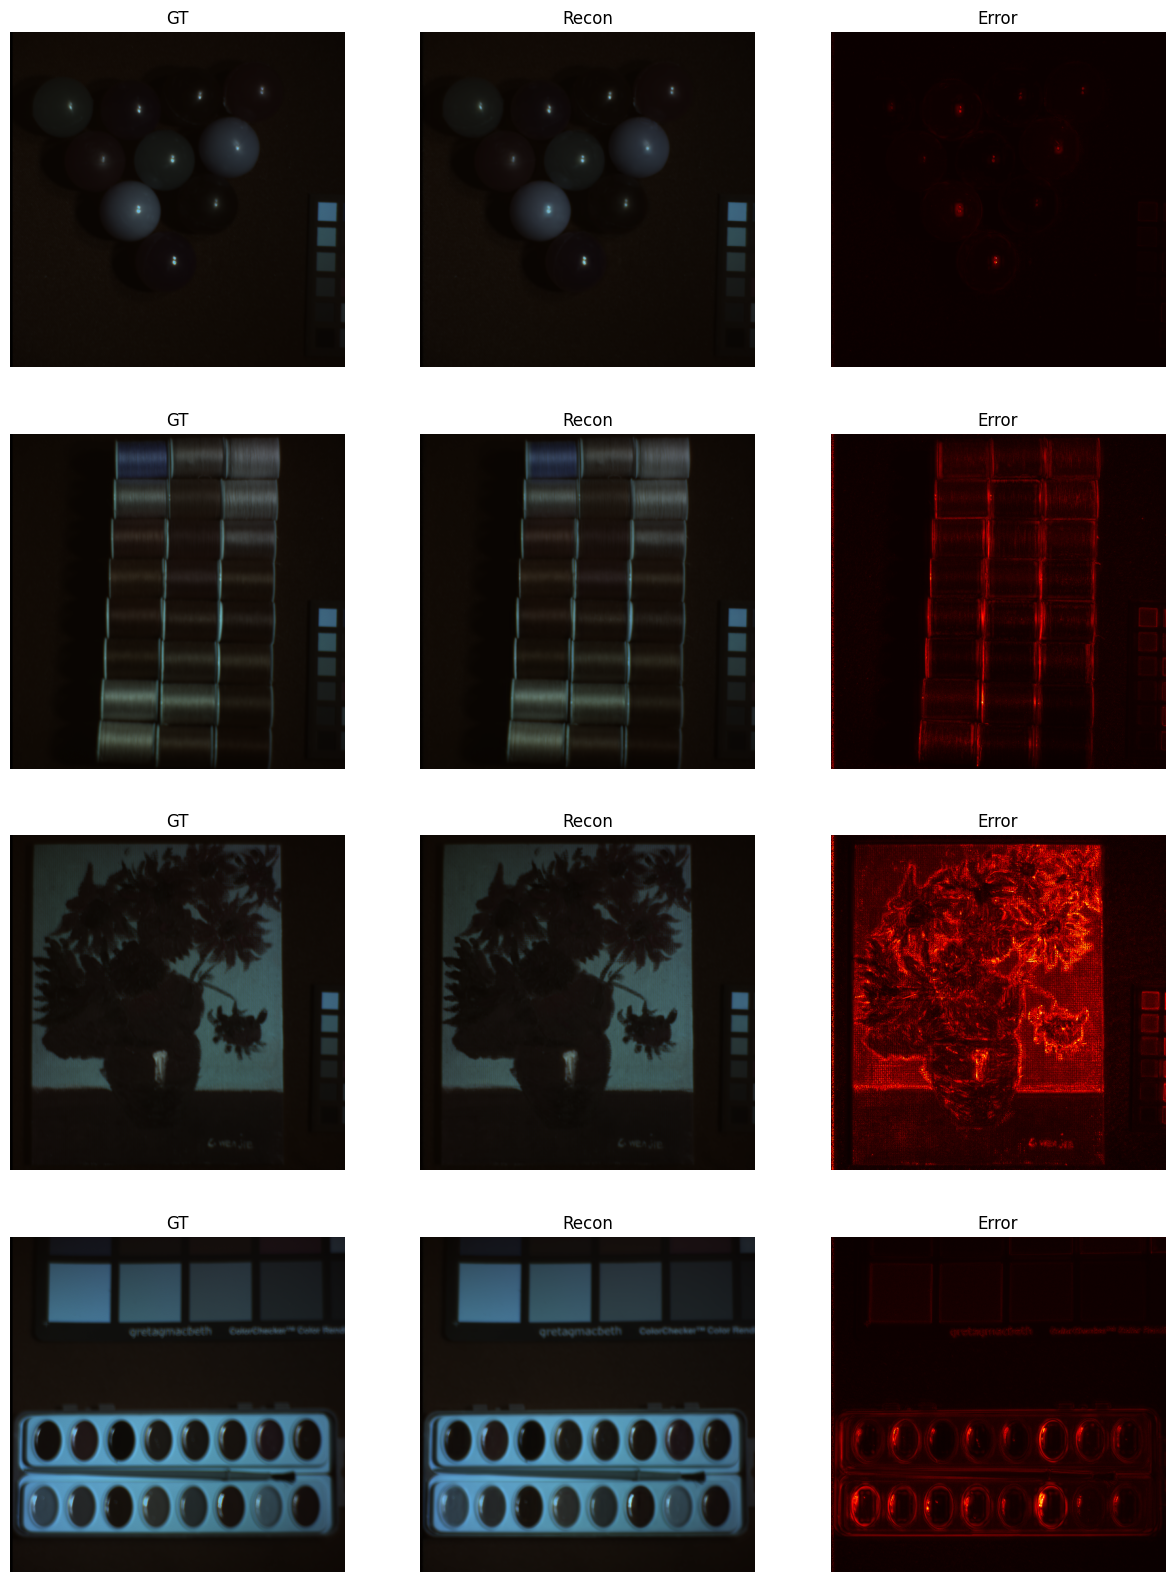

In [32]:
srf_path = '/kaggle/working/DHIF-Net/CAVE/Dataloader_tool/srflib/NikonD700.npy'
SRF = np.load(srf_path) if os.path.exists(srf_path) else None
def to_rgb(h):
    return np.clip(h @ SRF, 0, 1) if SRF is not None else np.clip(h[:, :, :3], 0, 1)
n = min(4, len(results))
if n > 0:
    fig, ax = plt.subplots(n, 3, figsize=(15, 5*n))
    for i in range(n):
        r = results[i]
        ax[i,0].imshow(to_rgb(r['gt'])); ax[i,0].set_title('GT'); ax[i,0].axis('off')
        ax[i,1].imshow(to_rgb(r['pred'])); ax[i,1].set_title('Recon'); ax[i,1].axis('off')
        ax[i,2].imshow(np.abs(r['gt']-r['pred']).mean(-1), cmap='hot'); ax[i,2].set_title('Error'); ax[i,2].axis('off')
    plt.show()
